Logistic regression 

Не величины, а классификация

Бинарная классификация - на 2 класса А и В: да/нет, есть/отсутствует, +/-, 0/1 и т.д.

Обычно взаимоисключающие вещи  

В общем случае можно свести к 0 и 1, где 1 это наличие признака, а 0 отсутствие.

Дихотомическая переменная.

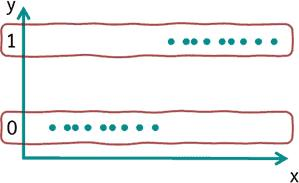

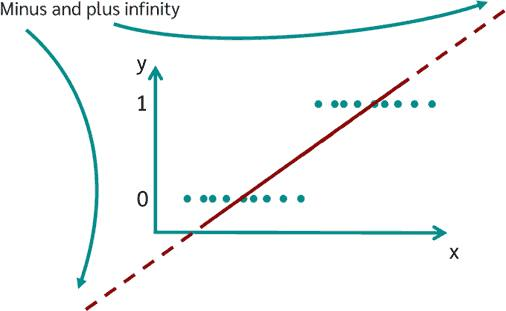

Вместо величины и бесконечных хвостов нам нужно предсказать вероятность класса 1 
р(у=1) = 0...1

Это можно сделать с помощью Logistic function

'Normal' (антисимметрична в нуле и типичная ширина)
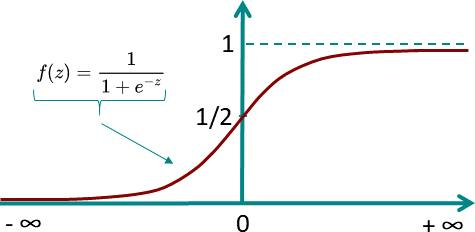

Монотонно отображает весь интервал на 0...1 

р(у=1) > 0.5 => class 1 
p(y=1) < 0.5 => class 0 

0.5 threshold ()

Модель нелинейна за счёт Логистической функции


In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

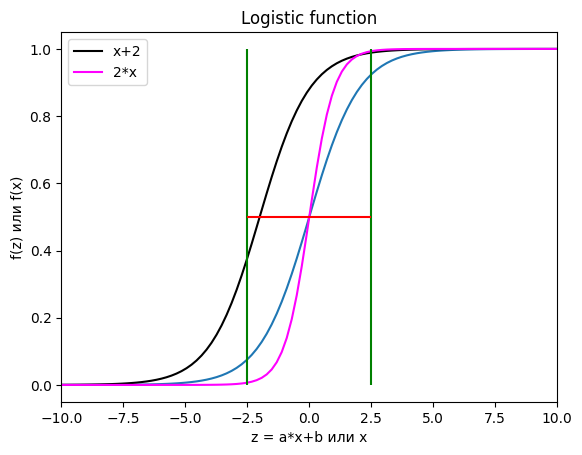

In [28]:
z = np.linspace(-10, 10, 100)
f = 1/(1+np.exp(-z))
x = np.linspace(-10, 10, 100)
f_p2 = 1/(1+np.exp(-(x+2))) # intersection
f_m2 = 1/(1+np.exp(-(2*x+0))) 
ax = sns.lineplot(x=z, y=f)
ax.plot(x, f_p2, color='k', label='x+2')
ax.plot(x, f_m2, color='magenta', label='2*x')
ax.set_xlim(-10, 10)
ax.vlines(-2.5, 0, 1, color='g')
ax.vlines(2.5, 0, 1, color='g')
ax.hlines(1/2, -5/2, 5/2, color='r')
ax.set_title('Logistic function')
ax.set_xlabel('z = a*x+b или х')
ax.set_ylabel('f(z) или f(x)')
ax.legend()
#ax.legend(['z',None,'x+2','2*x'])

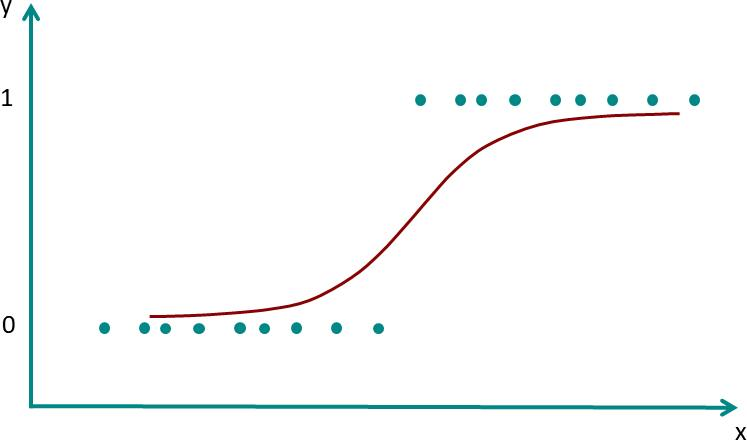

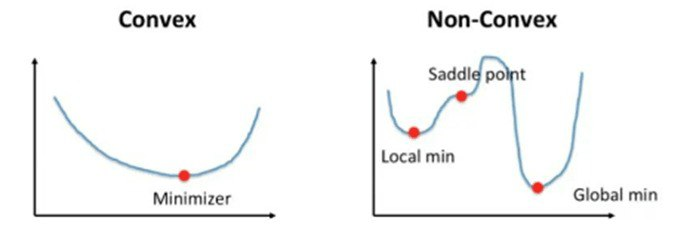

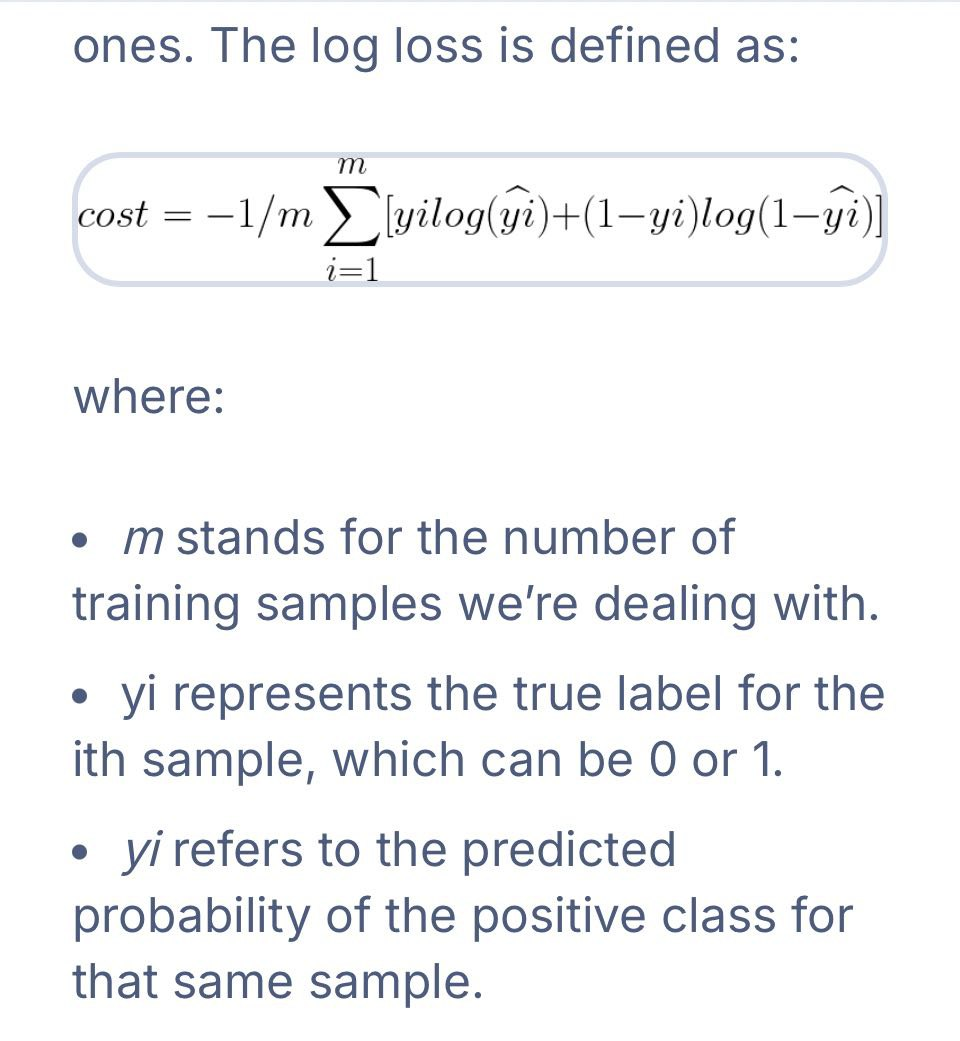

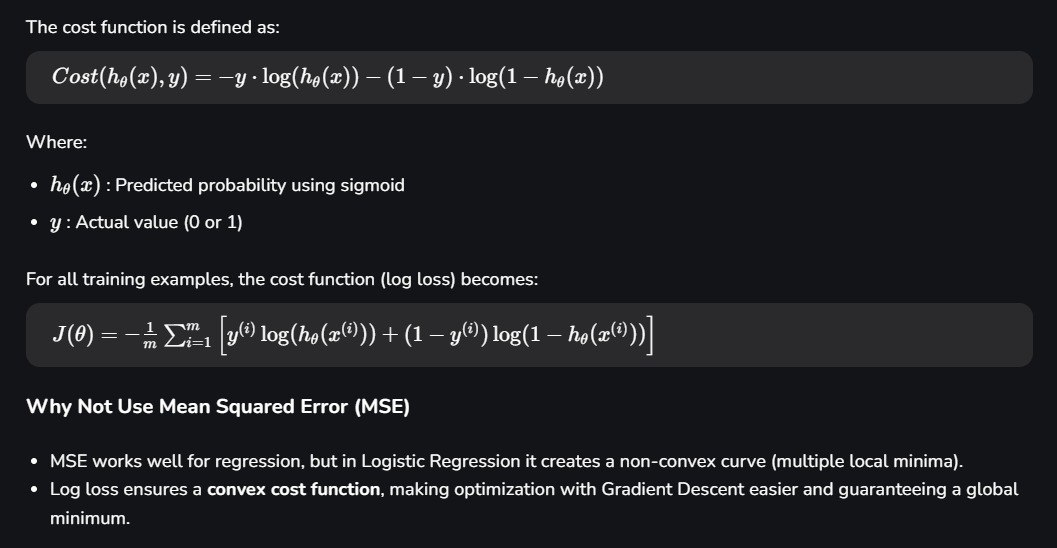

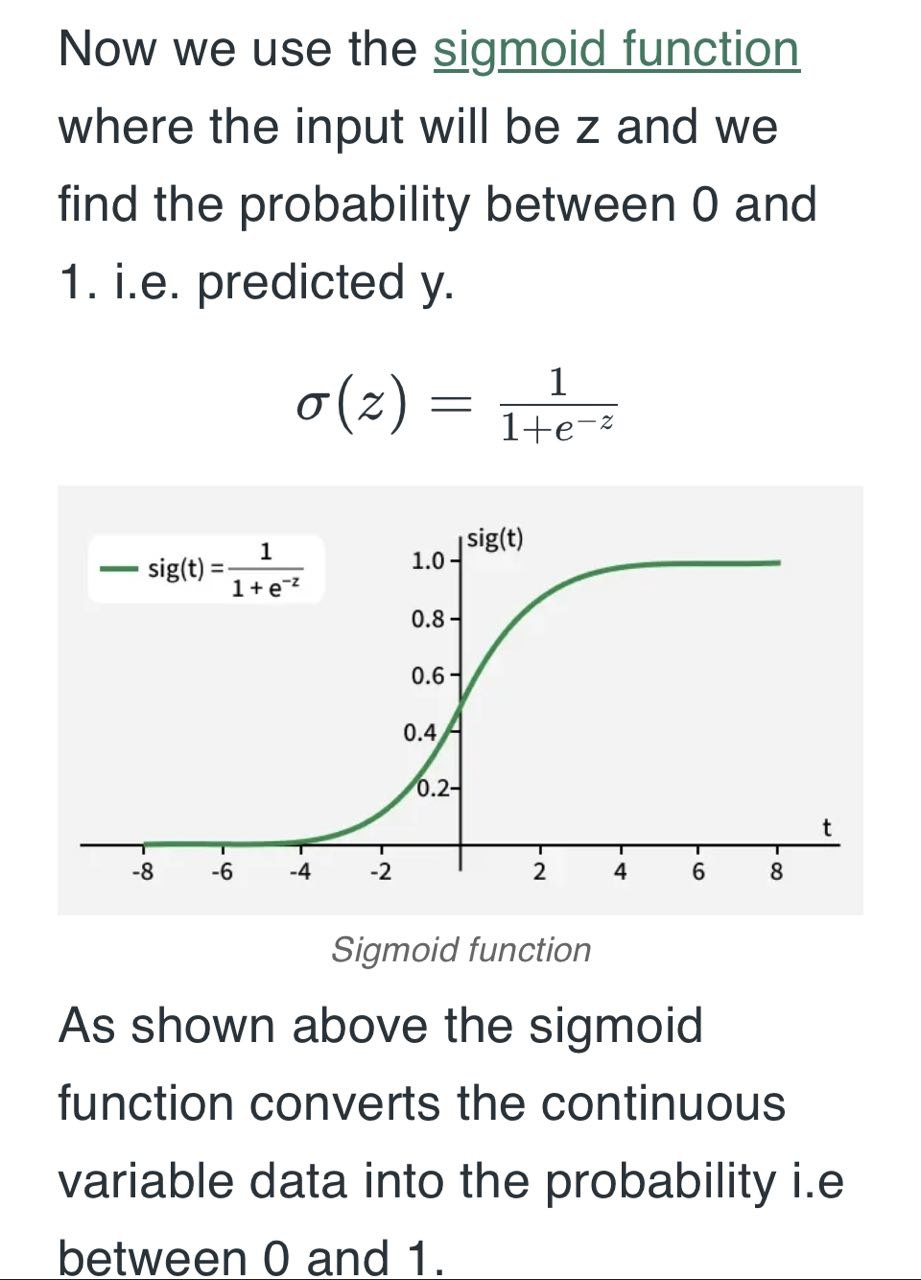

Odds - шансы , что событие случится как отношение вероятностей события к не событиям

p(x)/(1- p(x)) = e^z


z = w*x + b
(w_1*x+b)
w_1*x_1 + w_2*x_2 + ... + w_n*x_n + b
w = (w_1, ..., w_n) - горизонтальный вектор или строка
x = (x_1,
     X_2,
     ...,
     x_n) - вертикальный вектор или столебц

Далее матричное перемножение 


p(x; b, w) = 1/(1+e^(-z))

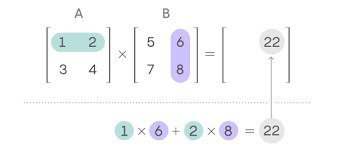

Bernoulli Distribution

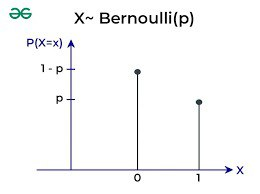

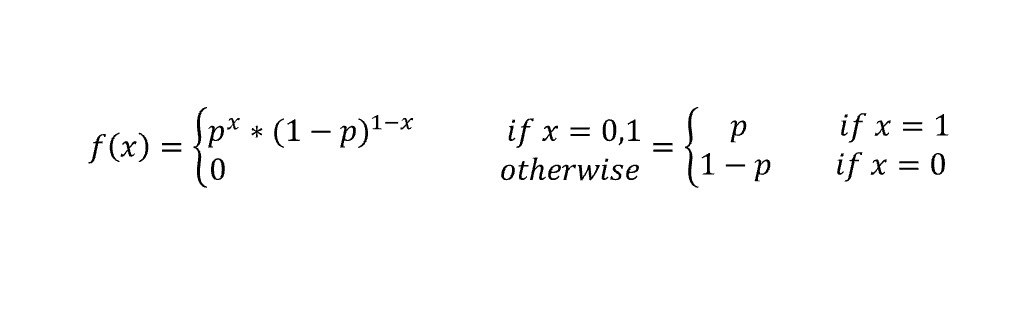
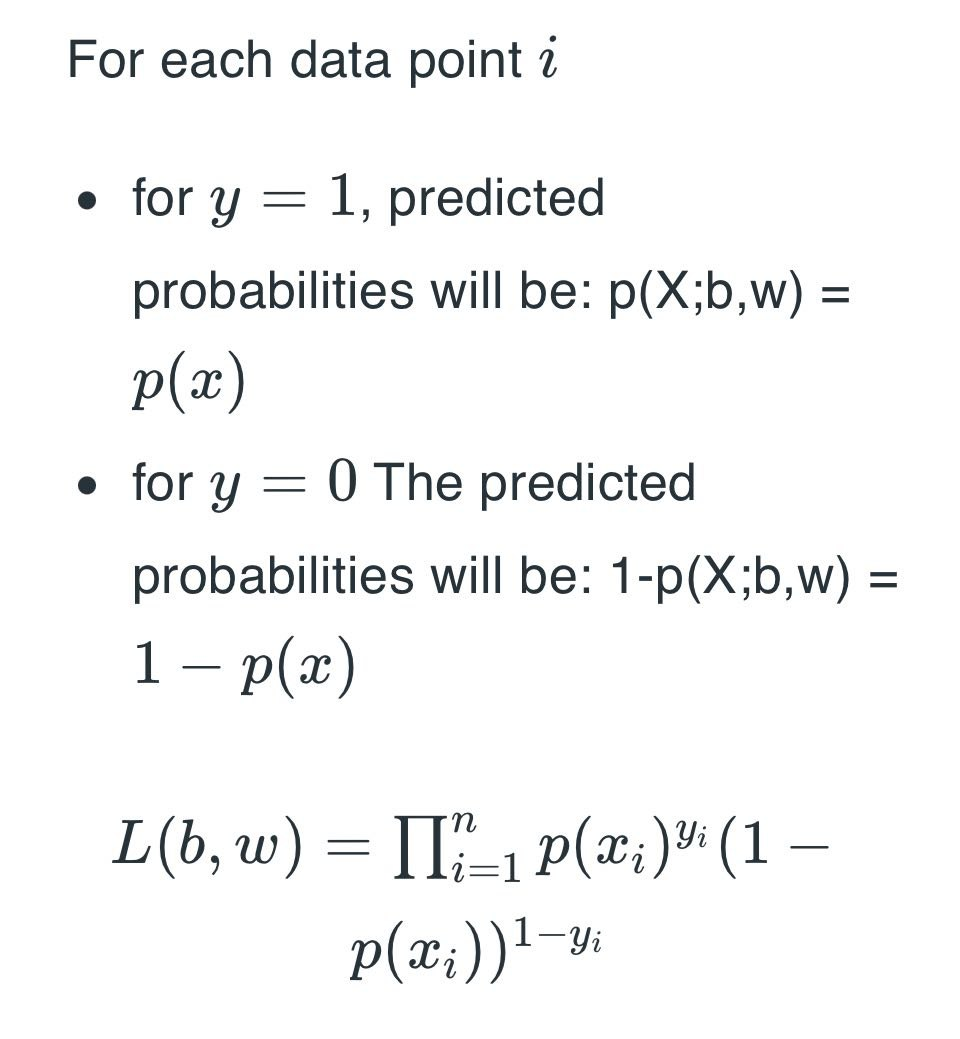

LIKELIHOOD 

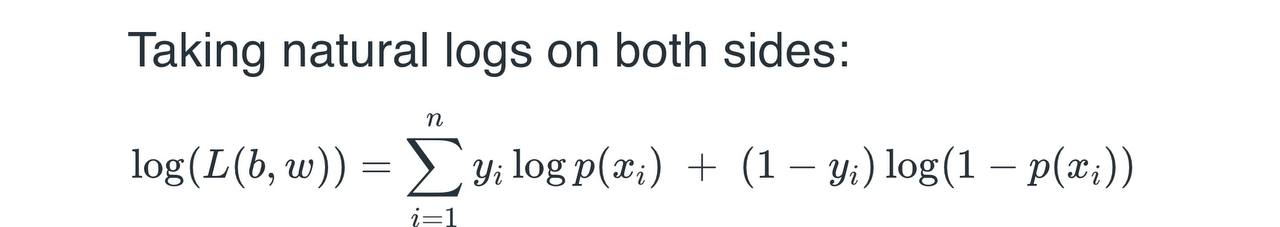

In [29]:
from sklearn.datasets import load_breast_cancer

In [30]:
data = load_breast_cancer(as_frame=True)

In [31]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [32]:
df = data['frame']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [33]:
df.target.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [34]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

<Axes: xlabel='target', ylabel='count'>

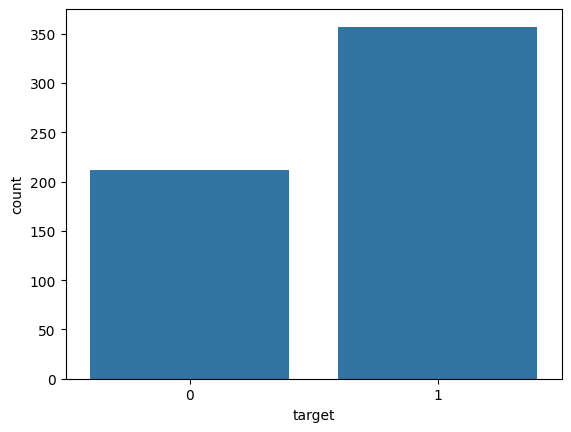

In [35]:
sns.barplot(df.target.value_counts())

Заметим дисбаланс классов - что может повлиять на качество модели

In [36]:
df_features = df.drop(['target'], axis=1)
df_features.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

In [65]:
X = df_features.to_numpy()
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [66]:
Y = df.target.to_numpy() # target - целевая (класс)
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [67]:
df_features.describe().T.sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
fractal dimension error,569.0,0.003795,0.002646,0.000895,0.002248,0.003187,0.004558,0.02984
smoothness error,569.0,0.007041,0.003003,0.001713,0.005169,0.006380,0.008146,0.03113
concave points error,569.0,0.011796,0.006170,0.000000,0.007638,0.010930,0.014710,0.05279
symmetry error,569.0,0.020542,0.008266,0.007882,0.015160,0.018730,0.023480,0.07895
compactness error,569.0,0.025478,0.017908,0.002252,0.013080,0.020450,0.032450,0.13540
concavity error,569.0,0.031894,0.030186,0.000000,0.015090,0.025890,0.042050,0.39600
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744
worst fractal dimension,569.0,0.083946,0.018061,0.055040,0.071460,0.080040,0.092080,0.20750
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680


In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()

In [70]:
X_scaled = scaler.fit_transform(X)

In [71]:
X_scaled.mean(axis=0)

array([-3.16286735e-15, -6.53060890e-15, -7.07889127e-16, -8.79983452e-16,
        6.13217737e-15, -1.12036918e-15, -4.42138027e-16,  9.73249991e-16,
       -1.97167024e-15, -1.45363120e-15, -9.07641468e-16, -8.85349205e-16,
        1.77367396e-15, -8.29155139e-16, -7.54180940e-16, -3.92187747e-16,
        7.91789988e-16, -2.73946068e-16, -3.10823423e-16, -3.36676596e-16,
       -2.33322442e-15,  1.76367415e-15, -1.19802625e-15,  5.04966114e-16,
       -5.21317026e-15, -2.17478837e-15,  6.85645643e-16, -1.41265636e-16,
       -2.28956670e-15,  2.57517109e-15])

In [72]:
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.20, random_state=42)

In [75]:
len(Y_test)/len(Y)

0.20035149384885764

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
lr = LogisticRegression()

In [78]:
lr.fit(X_train, Y_train) # Ищет минимум - log(LIKELIHOOD) путём поиска w(weight) и b(bias)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Логистическая регрессия - классическое начало машинного обучения

In [81]:
Y_pred = lr.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score

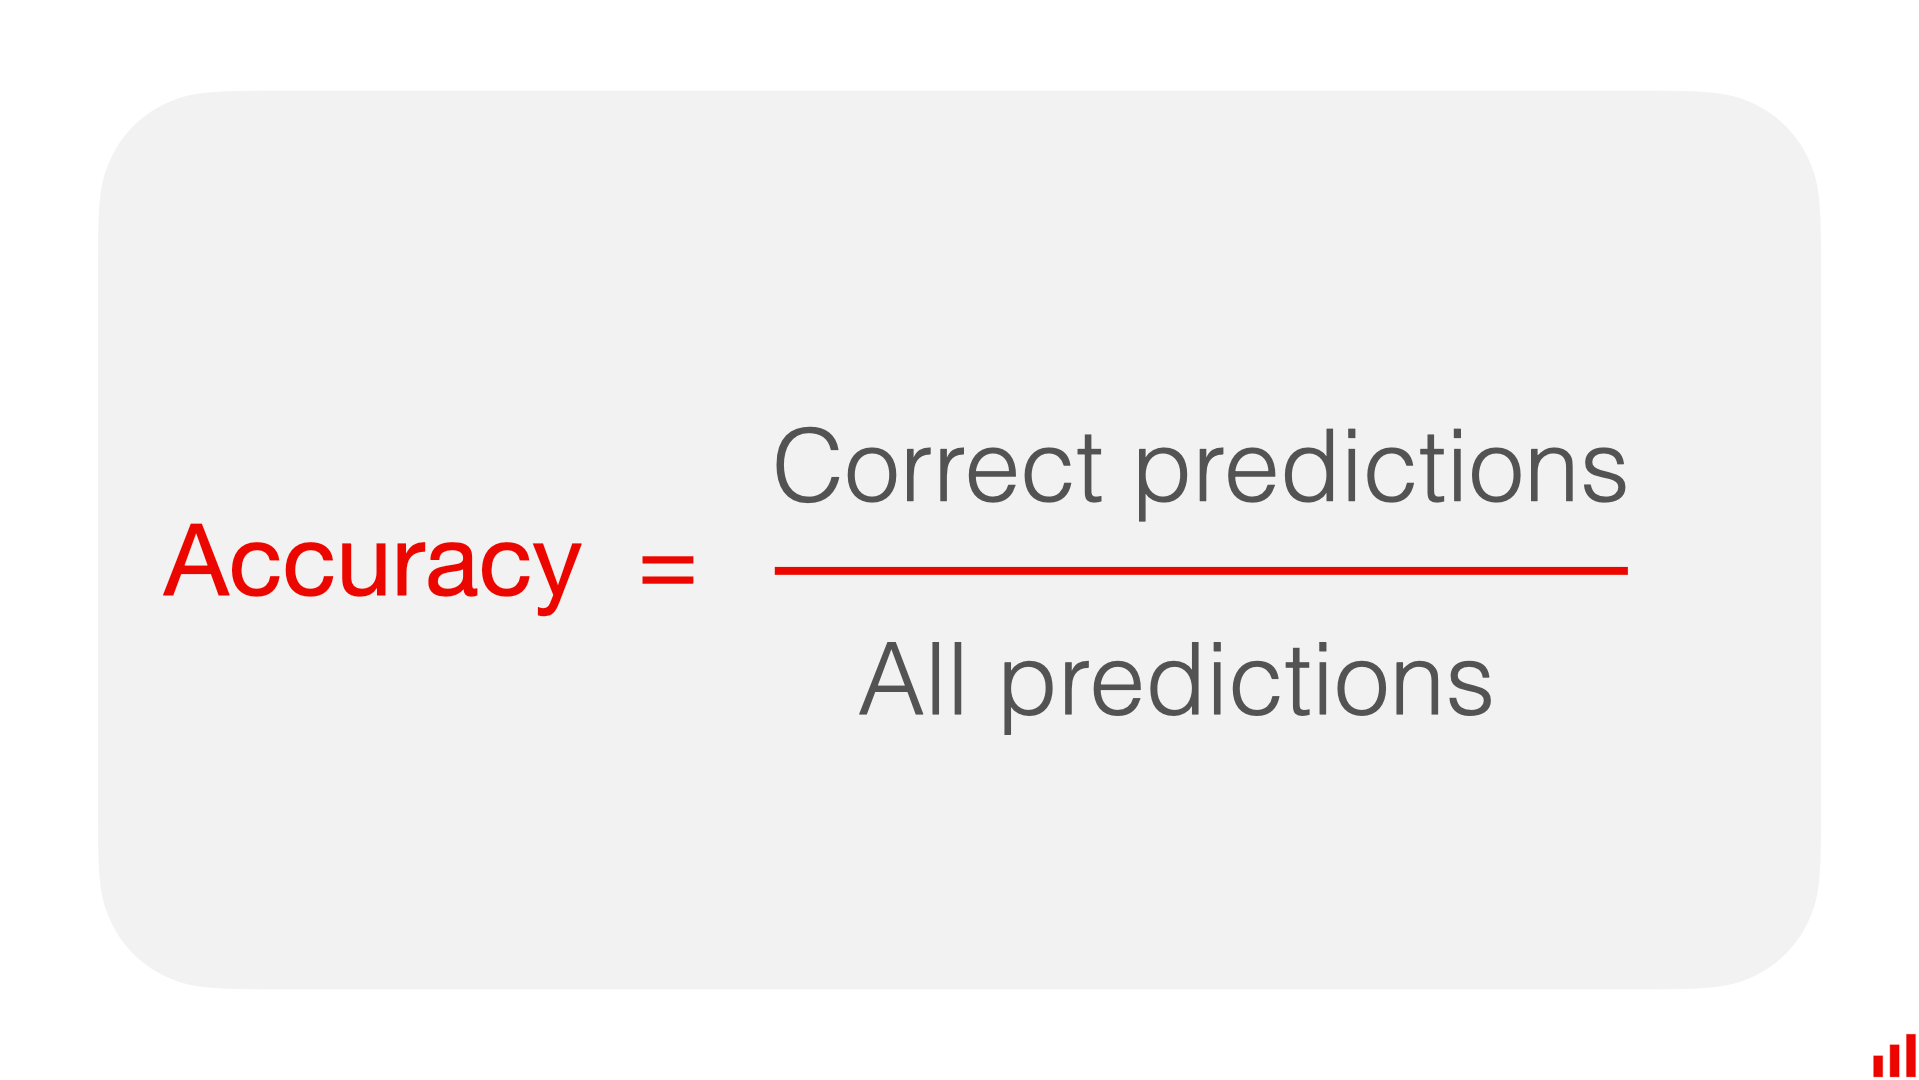

То есть количество правильно предсказанных 0 и 1 ко всем 


(ожидали ноль получили ноль, ожидали 1 получили 1) ко всем


A = (sum(0-->0) + sum(1-->1)) / (sum(x-->y))

In [83]:
f"Accuracy={accuracy_score(Y_test, Y_pred):.2f}"

'Accuracy=0.97'

In [84]:
((Y_test - Y_pred)==0).sum()/Y_test.size

np.float64(0.9736842105263158)

In [85]:
((Y_test - Y_pred)!=0).sum()/Y_test.size

np.float64(0.02631578947368421)

In [86]:
(~((Y_test - Y_pred)==0)).sum()/Y_test.size

np.float64(0.02631578947368421)

2 варианта записи ! 

см. выше

In [91]:
lr.coef_ # WEIGHT

array([[-0.43464701, -0.39719369, -0.39606985, -0.46999027, -0.06739432,
         0.52671658, -0.80767618, -1.1077114 ,  0.24153785,  0.07844689,
        -1.25057276,  0.1889927 , -0.58988574, -0.91987672, -0.31656977,
         0.66906627,  0.17107672, -0.31431731,  0.50499861,  0.61176062,
        -0.87394431, -1.35751246, -0.58604724, -0.83803013, -0.54737794,
         0.00589749, -0.95168648, -0.78040785, -1.19559714, -0.16293183]])

In [92]:
len(lr.coef_.flatten()) 

30

In [93]:
lr.intercept_  # BIAS

array([0.32857199])